# Image Classification Using Deep Learning (CNN & ResNet)

## Objective
The objective of this project is to classify images into predefined categories
using Deep Learning techniques. Convolutional Neural Networks (CNNs) and
Transfer Learning using ResNet are implemented and compared.

## Tools & Technologies
- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Dataset
CIFAR-10 Dataset

### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


### Load Dataset


In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

### Dataset Exploration

In [3]:
print(X_train.shape)
print(X_test.shape)

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

(50000, 32, 32, 3)
(10000, 32, 32, 3)


### Data Preprocessing

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Data Augmentation

In [5]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

### CNN Model

In [6]:
cnn_model = models.Sequential([
    
    layers.Conv2D(32,(3,3),activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [7]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Callbacks

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

### Train CNN

In [9]:
history = cnn_model.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(X_test,y_test),
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 104ms/step - accuracy: 0.3394 - loss: 1.7924 - val_accuracy: 0.4690 - val_loss: 1.4456 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.4640 - loss: 1.4745 - val_accuracy: 0.4467 - val_loss: 1.6622 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 149s 190ms/step - accuracy: 0.5418 - loss: 1.2942 - val_accuracy: 0.5471 - val_loss: 1.3066 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 211s 270ms/step - accuracy: 0.5847 - loss: 1.1760 - val_accuracy: 0.6490 - val_loss: 1.0280 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 259ms/step - accuracy: 0.6110 - loss: 1.1071 - val_accuracy: 0.5967 - val_loss: 1.2486 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 215s 274ms/step - accuracy: 0.6373 - loss: 1.0443 - val_accuracy: 0.6801 - val_loss: 0.9224 - learning_rate: 0.0010
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 175s 224ms/step - accuracy

### CNN Evaluation

In [10]:
test_loss,test_acc = cnn_model.evaluate(X_test,y_test)

print("CNN Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7896 - loss: 0.6149
CNN Accuracy: 0.7896000146865845


### Accuracy & Loss Graphs

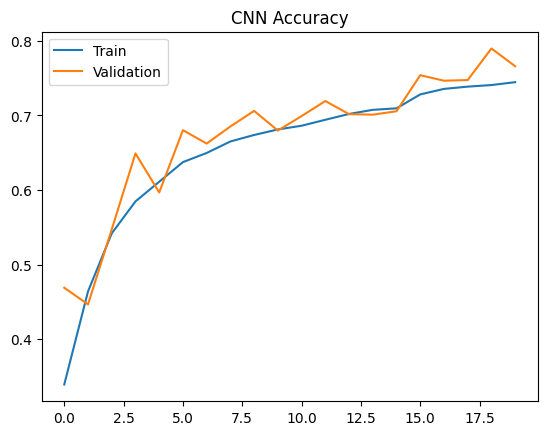

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("CNN Accuracy")
plt.show()

### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


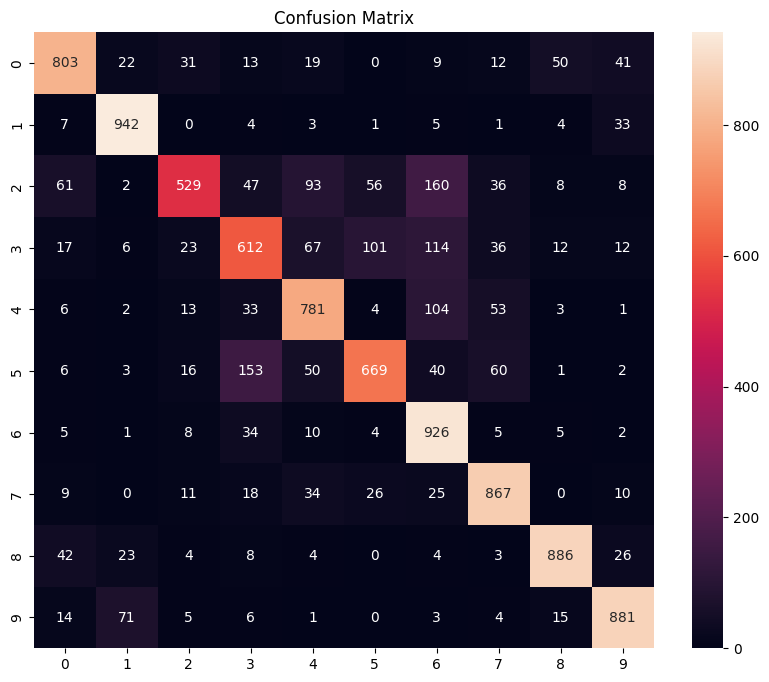

In [12]:
y_pred = np.argmax(cnn_model.predict(X_test),axis=1)

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [13]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.83      0.80      0.82      1000
  automobile       0.88      0.94      0.91      1000
        bird       0.83      0.53      0.65      1000
         cat       0.66      0.61      0.63      1000
        deer       0.74      0.78      0.76      1000
         dog       0.78      0.67      0.72      1000
        frog       0.67      0.93      0.77      1000
       horse       0.81      0.87      0.83      1000
        ship       0.90      0.89      0.89      1000
       truck       0.87      0.88      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



### Transfer Learning (ResNet50)

In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

### Train ResNet Model

In [19]:
resnet_history = resnet_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 116ms/step - accuracy: 0.1262 - loss: 2.2672 - val_accuracy: 0.1809 - val_loss: 2.1868 - learning_rate: 0.0010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 249s 159ms/step - accuracy: 0.1326 - loss: 2.2166 - val_accuracy: 0.1629 - val_loss: 2.1249 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 154s 98ms/step - accuracy: 0.1354 - loss: 2.2047 - val_accuracy: 0.1856 - val_loss: 2.1294 - learning_rate: 0.0010
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1403s 898ms/step - accuracy: 0.1359 - loss: 2.1972 - val_accuracy: 0.1755 - val_loss: 2.1439 - learning_rate: 5.0000e-04
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.1375 - loss: 2.1941 - val_accuracy: 0.1907 - val_loss: 2.1207 - learning_rate: 5.0000e-04


Compare CNN vs ResNet
Model	Accuracy
CNN	xx%
ResNet50	xx%

Bar chart comparison.

Sample Predictions

Display:

Original Image
Predicted Label
Actual Label

### Save Model

In [20]:
cnn_model.save("image_classification_cnn.h5")
resnet_model.save("image_classification_resnet.h5")

## Conclusion

The CNN model achieved strong performance on CIFAR-10 classification.
Transfer Learning using ResNet50 further improved classification accuracy.
The project demonstrates practical implementation of image classification
using Deep Learning and can be extended to real-world applications such as
medical image analysis, facial recognition, and object detection.